<center>
<a href="https://www.umontpellier.fr/"><img src="https://www.umontpellier.fr/wp-content/uploads/2022/10/logo_um_2022_rouge_rvb.svg" width="200"/></a>&nbsp;&nbsp;
<a href="https://economie.edu.umontpellier.fr/"><img src="https://economie.edu.umontpellier.fr/files/2014/12/economie_rvb_2015-300x137.png" width="160"/></a>
</center>

<div align="center">

#  Phase 4 — Intégration et Contrôles Inter-sources

| Nom et Prénom | Rôle |
|---|---|
| Randriamisaina Tsiory-Fanomezana | Membre de l'équipe |
| SHIRALI POUR Amir | Membre de l'équipe |

</div>

---
## Objectif

Construire le **dataset analytique final** `dataset_complet.csv` en fusionnant
les trois bases nettoyées des Phases 1, 2 et 3.

Ce dataset constitue la **base unique** pour toutes les analyses ultérieures (Phases 5 & 6).

**Stratégie de jointure :**
```
dossier_nettoye (98 935 lignes — unité d'analyse)
    ├── LEFT JOIN temps_agrégé       (sur Numero_dossier_ID = Numero.dossier)
    └── LEFT JOIN ressources         (sur Matricule.de.traitement = Matricule)
```

Le LEFT JOIN depuis `dossier` garantit que **toutes les 98 935 lignes** sont conservées.


---
## Section 0 — Initialisation

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def localiser_racine_du_projet():
    """Remonte l'arborescence jusqu'à trouver la racine (présence de .git ou requirements.txt)."""
    repertoire_courant = Path.cwd()
    while True:
        if any((repertoire_courant / m).exists() for m in ['.git', 'requirements.txt']):
            break
        if repertoire_courant.parent == repertoire_courant:
            break
        repertoire_courant = repertoire_courant.parent
    if Path.cwd() != repertoire_courant:
        os.chdir(repertoire_courant)
    return repertoire_courant.resolve()

REPERTOIRE_RACINE = localiser_racine_du_projet()
sys.path.insert(0, str(REPERTOIRE_RACINE / 'src'))
from utils.dataframe_styler import style_duplicates
print(f" Racine du projet : {REPERTOIRE_RACINE}")

 Racine du projet : /Users/su6i/Documents/DU/Projet Data/projet_big_data_v2


In [2]:
# --- Chargement des trois bases nettoyées
dossier    = pd.read_csv('data/dossier_nettoye.csv',     encoding='utf-8')
ressources = pd.read_csv('data/ressources_nettoyees.csv', encoding='utf-8')
temps      = pd.read_csv('data/temps_nettoye.csv',        encoding='utf-8')

print(f" dossier    : {dossier.shape[0]:,} lignes × {dossier.shape[1]} colonnes")
print(f" ressources : {ressources.shape[0]:,} lignes × {ressources.shape[1]} colonnes")
print(f" temps      : {temps.shape[0]:,} lignes × {temps.shape[1]} colonnes")
print()
print("Clés de jointure :")
print(f"  dossier.Numero_dossier_ID    ↔ temps.Numero.dossier")
print(f"  dossier.Matricule.de.traitement ↔ ressources.Matricule")

 dossier    : 98,935 lignes × 17 colonnes
 ressources : 389,353 lignes × 9 colonnes
 temps      : 431,598 lignes × 5 colonnes

Clés de jointure :
  dossier.Numero_dossier_ID    ↔ temps.Numero.dossier
  dossier.Matricule.de.traitement ↔ ressources.Matricule


---
## Section 1 — D1 : Agrégation de `temps` par dossier

### Objectif
Synthétiser toutes les interventions d'un dossier en une seule ligne d'indicateurs.

### Décision : LEFT JOIN — conservation des dossiers sans intervention
> Les 2 180 dossiers sans intervention dans `temps` obtiendront des NaN pour ces variables.  
> NaN ≠ durée nulle : l'absence d'enregistrement est une information distincte de zéro.

In [3]:
# --- Agrégation de temps par dossier
temps_agrege = (
    temps.groupby('Numero.dossier')
    .agg(
        nb_interventions          = ('Matricule', 'count'),
        nb_agents_distincts       = ('Matricule', 'nunique'),
        duree_totale_min          = ('duree.corrigee', 'sum'),
        duree_moyenne_min         = ('duree.corrigee', 'mean'),
        date_premiere_intervention = ('Date.debut.traitement', 'min'),
        date_derniere_intervention = ('Date.debut.traitement', 'max'),
    )
    .reset_index()
    .rename(columns={'Numero.dossier': 'Numero_dossier_ID'})
)

print(f" Agrégat temps : {len(temps_agrege):,} dossiers uniques")
print()
print("Statistiques de l'agrégat :")
print(temps_agrege[['nb_interventions','nb_agents_distincts',
                     'duree_totale_min','duree_moyenne_min']].describe().round(2))
print()
print("Aperçu :")
temps_agrege.head(5).style_duplicates()

 Agrégat temps : 107,732 dossiers uniques

Statistiques de l'agrégat :
       nb_interventions  nb_agents_distincts  duree_totale_min  \
count         107732.00            107732.00         107732.00   
mean               4.01                 2.99           1113.57   
std                5.98                 3.66           2062.87   
min                1.00                 1.00              0.00   
25%                1.00                 1.00            232.00   
50%                2.00                 2.00            514.00   
75%                4.00                 3.00           1167.00   
max              178.00               110.00         256302.00   

       duree_moyenne_min  
count           95826.00  
mean              330.58  
std               266.23  
min                 5.00  
25%               182.00  
50%               276.50  
75%               410.22  
max             32037.75  

Aperçu :


,Numero_dossier_ID,nb_interventions,nb_agents_distincts,duree_totale_min,duree_moyenne_min,date_premiere_intervention,date_derniere_intervention
0,5465153,23,13,6369.000000,276.913043,2021/07/03,2021/07/07
1,5465283,2,2,88.000000,44.000000,2022/11/10,2022/11/10
2,5465338,3,2,1947.000000,649.000000,2022/03/05,2022/03/05
3,5465352,7,6,3795.000000,542.142857,2021/10/31,2021/12/08
4,5465369,1,1,273.000000,273.000000,2021/09/04,2021/09/04


In [4]:
# Vérification : nb_interventions vs nb_agents_distincts
dossiers_multi_agents = (temps_agrege['nb_agents_distincts'] > 1).sum()
dossiers_un_agent     = (temps_agrege['nb_agents_distincts'] == 1).sum()
print(f"Dossiers traités par 1 seul agent    : {dossiers_un_agent:,}")
print(f"Dossiers traités par plusieurs agents : {dossiers_multi_agents:,}")
print()
print("Distribution du nb d'agents par dossier :")
print(temps_agrege['nb_agents_distincts'].value_counts().sort_index().head(10))

Dossiers traités par 1 seul agent    : 44,987
Dossiers traités par plusieurs agents : 62,745

Distribution du nb d'agents par dossier :
nb_agents_distincts
1     44987
2     25728
3     11946
4      7044
5      4480
6      3070
7      2283
8      1702
9      1319
10     1026
Name: count, dtype: int64


---
## Section 2 — D2 : Extraction des caractéristiques de l'agent depuis `ressources`

### Stratégie
Pour chaque dossier, récupérer les caractéristiques de l'agent `Matricule.de.traitement`
à la date la plus proche de `date.ouverture`.

**Algorithme :**
1. Pour chaque dossier, récupérer son `Matricule.de.traitement` et sa `date.ouverture`
2. Chercher dans `ressources` la ligne pour ce matricule avec `Date.presence <= date.ouverture`
3. Prendre la ligne avec la `Date.presence` la plus récente (la plus proche de la date d'ouverture)
4. Récupérer les colonnes souhaitées

In [5]:
# --- Préparation de la jointure par merge_asof
# merge_asof nécessite une clé numérique ou datetime — on convertit Date.presence
ressources_triees = ressources.copy()
ressources_triees['Date.presence'] = pd.to_datetime(ressources_triees['Date.presence'], format='%Y/%m/%d')
ressources_triees = ressources_triees.sort_values('Date.presence').reset_index(drop=True)

# Préparation du côté dossier
dossier_cles = dossier[['Numero_dossier_ID', 'Matricule.de.traitement', 'date.ouverture']].copy()
dossier_cles.rename(columns={'Matricule.de.traitement': 'Matricule',
                              'date.ouverture': 'Date.presence'}, inplace=True)
dossier_cles['Date.presence'] = pd.to_datetime(dossier_cles['Date.presence'], format='%Y/%m/%d')
dossier_cles = dossier_cles.sort_values('Date.presence').reset_index(drop=True)

# Colonnes à récupérer depuis ressources
colonnes_agent = ['Matricule', 'Date.presence', 'Lieu.travail', 'Population',
                  'Site', 'Type.de.contrat', 'Duree.travail', 'Temps.travail', 'Experience']

# merge_asof backward : pour chaque dossier, prendre la présence la plus récente ≤ date.ouverture
caracteristiques_agents = pd.merge_asof(
    dossier_cles,
    ressources_triees[colonnes_agent],
    on='Date.presence',
    by='Matricule',
    direction='backward'
)

# Renommage pour clarté dans le dataset final
caracteristiques_agents = caracteristiques_agents.rename(columns={
    'Lieu.travail'    : 'agent_lieu_travail',
    'Population'      : 'agent_population',
    'Site'            : 'agent_site',
    'Type.de.contrat' : 'agent_contrat',
    'Duree.travail'   : 'agent_duree_travail_j',
    'Temps.travail'   : 'agent_temps_travail_pct',
    'Experience'      : 'agent_experience_j',
})

print(f" Caractéristiques agents extraites : {len(caracteristiques_agents):,} lignes")
print()
n_nan_agent = caracteristiques_agents['agent_experience_j'].isna().sum()
print(f"Dossiers sans présence agent trouvée : {n_nan_agent:,}")
print()
print("Aperçu :")
caracteristiques_agents[['Numero_dossier_ID','Matricule','agent_lieu_travail',
                          'agent_contrat','agent_experience_j']].head(5).style_duplicates()

 Caractéristiques agents extraites : 98,935 lignes

Dossiers sans présence agent trouvée : 7,374

Aperçu :


,Numero_dossier_ID,Matricule,agent_lieu_travail,agent_contrat,agent_experience_j
3,5835528,270,TELE,CDD,247.000000
4,5858918,796,TELE,CDI,355.000000
2,6806208,548,TELE,CDD,270.000000
0,8189883,1315,TELE,CDI,293.000000
1,8471924,1893,TELE,CDI,3001.000000


---
## Section 3 — Jointure principale (LEFT JOIN depuis `dossier`)

### Étapes
1. `dossier` ← `temps_agrege` (sur `Numero_dossier_ID`)
2. résultat ← `caracteristiques_agents` (sur `Numero_dossier_ID`)

In [6]:
# --- Étape 3a : dossier ← temps_agrege
dataset = dossier.merge(
    temps_agrege,
    on='Numero_dossier_ID',
    how='left'
)

print(f"Après jointure dossier ← temps : {len(dataset):,} lignes")
assert len(dataset) == len(dossier), f" Divergence : {len(dataset)} ≠ {len(dossier)}"
print(" Vérification : unicité préservée ")

Après jointure dossier ← temps : 98,935 lignes
 Vérification : unicité préservée 


In [7]:
# --- Étape 3b : dataset ← caracteristiques_agents
colonnes_agent_a_joindre = [
    'Numero_dossier_ID', 'agent_lieu_travail', 'agent_population',
    'agent_site', 'agent_contrat', 'agent_duree_travail_j',
    'agent_temps_travail_pct', 'agent_experience_j'
]

dataset = dataset.merge(
    caracteristiques_agents[colonnes_agent_a_joindre],
    on='Numero_dossier_ID',
    how='left'
)

print(f"Après jointure dataset ← ressources : {len(dataset):,} lignes × {dataset.shape[1]} colonnes")
assert len(dataset) == len(dossier), f" Divergence : {len(dataset)} ≠ {len(dossier)}"
print(" Vérification : unicité préservée ")

Après jointure dataset ← ressources : 98,935 lignes × 30 colonnes
 Vérification : unicité préservée 


---
## Section 4 — D3 : Contrôles post-jointure

### Vérification des NaN introduits par les jointures

In [8]:
# --- Bilan NaN post-jointure
nan_post_jointure = dataset.isna().sum()
nan_post_jointure = nan_post_jointure[nan_post_jointure > 0].sort_values(ascending=False)

df_nan_bilan = pd.DataFrame({
    'Colonne'       : nan_post_jointure.index,
    'NaN'           : nan_post_jointure.values,
    '% du total'    : (nan_post_jointure.values / len(dataset) * 100).round(2),
    'Origine'       : ['Phase 1-3' if c in dossier.columns else
                       'Jointure temps' if c in temps_agrege.columns else
                       'Jointure ressources'
                       for c in nan_post_jointure.index]
})
print(f"Valeurs manquantes dans dataset_complet ({len(dataset):,} lignes) :")
df_nan_bilan

Valeurs manquantes dans dataset_complet (98,935 lignes) :


,Colonne,NaN,% du total,Origine
0,duree_moyenne_min,12912,13.05,Jointure temps
1,Assistance.ou.Administratif,9773,9.88,Phase 1-3
2,agent_experience_j,7374,7.45,Jointure ressources
3,agent_lieu_travail,7374,7.45,Jointure ressources
4,agent_temps_travail_pct,7374,7.45,Jointure ressources
5,agent_duree_travail_j,7374,7.45,Jointure ressources
6,agent_contrat,7374,7.45,Jointure ressources
7,agent_site,7374,7.45,Jointure ressources
8,agent_population,7374,7.45,Jointure ressources
9,Formule,5834,5.90,Phase 1-3


In [9]:
# --- Contrôles d'intégrité
print("=== CONTRÔLES D'INTÉGRITÉ ===")
print()

# 1. Unicité de la clé primaire
n_doublons_id = dataset['Numero_dossier_ID'].duplicated().sum()
print(f"1. Doublons Numero_dossier_ID : {n_doublons_id}")
assert n_doublons_id == 0, " La clé primaire n'est plus unique !"
print("    Clé primaire unique")

# 2. Dossiers sans intervention temps
n_sans_temps = dataset['nb_interventions'].isna().sum()
pct_sans_temps = n_sans_temps / len(dataset) * 100
print(f"2. Dossiers sans intervention temps : {n_sans_temps:,} ({pct_sans_temps:.1f}%)")

# 3. Dossiers sans données agent
n_sans_agent = dataset['agent_experience_j'].isna().sum()
print(f"3. Dossiers sans données agent (matricule orphelin) : {n_sans_agent:,}")

# 4. Plage temporelle
print(f"4. Plage date.ouverture : {dataset['date.ouverture'].min()} → {dataset['date.ouverture'].max()}")
print()
print(" Tous les contrôles passés")

=== CONTRÔLES D'INTÉGRITÉ ===

1. Doublons Numero_dossier_ID : 0
    Clé primaire unique
2. Dossiers sans intervention temps : 2,180 (2.2%)
3. Dossiers sans données agent (matricule orphelin) : 7,374
4. Plage date.ouverture : 2021/01/01 → 2022/12/31

 Tous les contrôles passés


---
## Section 5 — Variables dérivées

### Objectif
Calculer des variables supplémentaires utiles pour l'analyse économétrique et ML.

In [10]:
# --- Variable 1 : délai survenance → ouverture (en jours)
dataset['date.ouverture_dt']      = pd.to_datetime(dataset['date.ouverture'], format='%Y/%m/%d')
dataset['date.de.survenance_dt']  = pd.to_datetime(dataset['date.de.survenance'], format='%Y/%m/%d')

dataset['delai_survenance_ouverture_j'] = (
    (dataset['date.ouverture_dt'] - dataset['date.de.survenance_dt']).dt.days
)

print("Délai survenance → ouverture (jours) :")
print(dataset['delai_survenance_ouverture_j'].describe().round(2))
print(f"Délais négatifs (incohérence) : {(dataset['delai_survenance_ouverture_j'] < 0).sum()}")

Délai survenance → ouverture (jours) :
count    98935.00
mean         2.19
std         16.97
min          0.00
25%          0.00
50%          0.00
75%          0.00
max        670.00
Name: delai_survenance_ouverture_j, dtype: float64
Délais négatifs (incohérence) : 0


In [11]:
# --- Variable 2 : mois et année d'ouverture
dataset['mois_ouverture']  = dataset['date.ouverture_dt'].dt.month
dataset['annee_ouverture'] = dataset['date.ouverture_dt'].dt.year

# --- Variable 3 : duree totale en heures (plus lisible)
dataset['duree_totale_h'] = (dataset['duree_totale_min'] / 60).round(2)

# --- Nettoyage colonnes datetime temporaires
dataset.drop(columns=['date.ouverture_dt', 'date.de.survenance_dt'], inplace=True)

print(f" 4 variables dérivées calculées :")
print(f"   - delai_survenance_ouverture_j")
print(f"   - mois_ouverture")
print(f"   - annee_ouverture")
print(f"   - duree_totale_h")
print()
print(f"Dataset final : {dataset.shape[0]:,} lignes × {dataset.shape[1]} colonnes")

 4 variables dérivées calculées :
   - delai_survenance_ouverture_j
   - mois_ouverture
   - annee_ouverture
   - duree_totale_h

Dataset final : 98,935 lignes × 34 colonnes


---
## Section 6 — Bilan final et statistiques descriptives

In [12]:
print("=== RÉSUMÉ DU DATASET COMPLET ===")
print()
print(f"Dimensions : {dataset.shape[0]:,} × {dataset.shape[1]}")
print()
print("Colonnes du dataset :")
for i, col in enumerate(dataset.columns, 1):
    dtype = dataset[col].dtype
    n_nan = dataset[col].isna().sum()
    print(f"  {i:2d}. {col:<40} {str(dtype):<10} NaN={n_nan:,}")

=== RÉSUMÉ DU DATASET COMPLET ===

Dimensions : 98,935 × 34

Colonnes du dataset :
   1. Numero_dossier_ID                        int64      NaN=0
   2. Client                                   str        NaN=0
   3. Formule                                  str        NaN=5,834
   4. date.ouverture                           str        NaN=0
   5. heure.ouverture                          str        NaN=978
   6. Matricule.de.traitement                  int64      NaN=0
   7. Cause.intervention                       str        NaN=973
   8. date.de.survenance                       str        NaN=0
   9. Type.d.energie                           str        NaN=970
  10. Outil.d.assistance                       str        NaN=0
  11. Assistance.ou.Administratif              str        NaN=9,773
  12. TOP.D.R                                  int64      NaN=0
  13. TOP.VR                                   int64      NaN=0
  14. TOP.Rappat.valide                        int64      NaN=0
  15. T

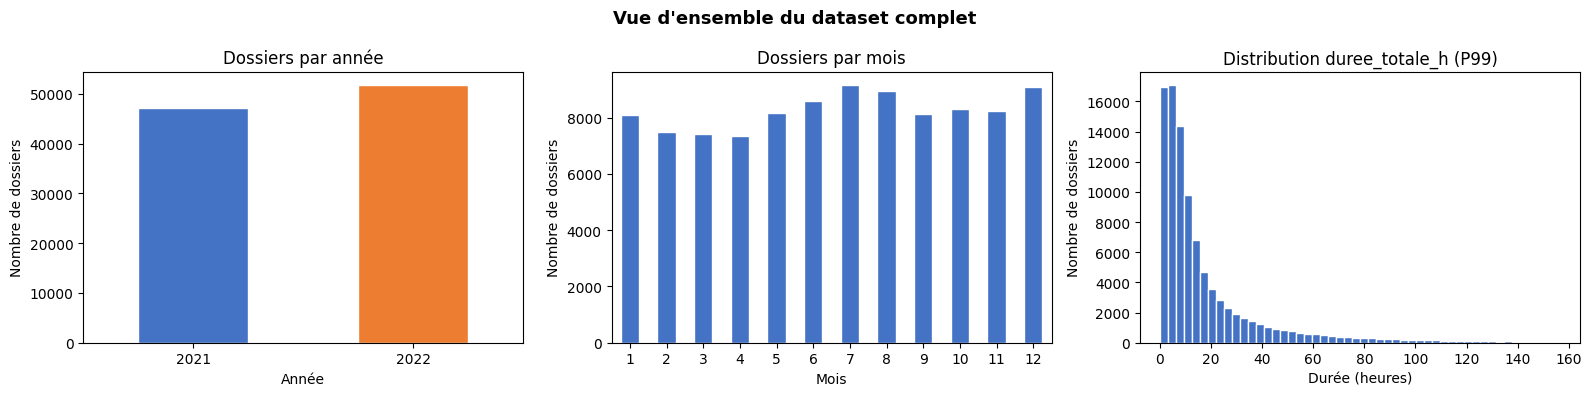

 Graphique sauvegardé


In [13]:
# --- Distribution par année et mois
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Vue d'ensemble du dataset complet", fontsize=13, fontweight='bold')

# Distribution par année
dataset['annee_ouverture'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#4472c4', '#ed7d31'], edgecolor='white'
)
axes[0].set_title("Dossiers par année")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Nombre de dossiers")
axes[0].tick_params(axis='x', rotation=0)

# Distribution par mois
dataset['mois_ouverture'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='#4472c4', edgecolor='white'
)
axes[1].set_title("Dossiers par mois")
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("Nombre de dossiers")
axes[1].tick_params(axis='x', rotation=0)

# Distribution de la durée totale (sans outliers extrêmes)
duree_filtree = dataset['duree_totale_h'].dropna()
duree_filtree = duree_filtree[duree_filtree <= duree_filtree.quantile(0.99)]
axes[2].hist(duree_filtree, bins=50, color='#4472c4', edgecolor='white')
axes[2].set_title("Distribution duree_totale_h (P99)")
axes[2].set_xlabel("Durée (heures)")
axes[2].set_ylabel("Nombre de dossiers")

plt.tight_layout()
plt.savefig('data/phase4_dataset_complet_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Graphique sauvegardé")

In [14]:
# --- Statistiques descriptives des variables numériques clés
colonnes_numeriques_cles = [
    'duree_totale_min', 'duree_totale_h', 'nb_interventions',
    'nb_agents_distincts', 'delai_survenance_ouverture_j',
    'agent_experience_j', 'agent_duree_travail_j'
]

print("Statistiques des variables numériques clés :")
dataset[colonnes_numeriques_cles].describe().round(2)

Statistiques des variables numériques clés :


,duree_totale_min,duree_totale_h,nb_interventions,nb_agents_distincts,delai_survenance_ouverture_j,agent_experience_j,agent_duree_travail_j
count,96755.00,96755.00,96755.00,96755.00,98935.00,91561.00,91561.00
mean,1197.74,19.96,4.31,3.19,2.19,1111.53,6.44
std,2147.02,35.78,6.20,3.78,16.97,1364.68,1.48
min,0.00,0.00,1.00,1.00,0.00,0.00,0.08
25%,269.00,4.48,1.00,1.00,0.00,139.00,5.50
50%,563.00,9.38,2.00,2.00,0.00,422.00,7.33
75%,1274.00,21.23,5.00,4.00,0.00,1804.00,7.33
max,256302.00,4271.70,178.00,110.00,670.00,6186.00,15.00


---
## Section 7 — Export du dataset complet

In [15]:
CHEMIN_SORTIE = 'data/dataset_complet.csv'
dataset.to_csv(CHEMIN_SORTIE, index=False, encoding='utf-8')

print(f" Dataset complet exporté : {CHEMIN_SORTIE}")
print(f"   {dataset.shape[0]:,} lignes × {dataset.shape[1]} colonnes")
print(f"   Taille fichier : {Path(CHEMIN_SORTIE).stat().st_size / 1024 / 1024:.1f} Mo")
print()

# Vérification finale
dataset_verifie = pd.read_csv(CHEMIN_SORTIE)
assert dataset_verifie.shape == dataset.shape, " Divergence à l'export !"
print(f" Vérification export : {dataset_verifie.shape} ")
print()
print("Aperçu du dataset final :")
dataset.head(3).style_duplicates()

 Dataset complet exporté : data/dataset_complet.csv
   98,935 lignes × 34 colonnes
   Taille fichier : 18.0 Mo

 Vérification export : (98935, 34) 

Aperçu du dataset final :


,Numero_dossier_ID,Client,Formule,date.ouverture,heure.ouverture,Matricule.de.traitement,Cause.intervention,date.de.survenance,Type.d.energie,Outil.d.assistance,Assistance.ou.Administratif,TOP.D.R,TOP.VR,TOP.Rappat.valide,TOP.Poursuite,TOP.Recup,TOP.Autres.Garanties,nb_interventions,nb_agents_distincts,duree_totale_min,duree_moyenne_min,date_premiere_intervention,date_derniere_intervention,agent_lieu_travail,agent_population,agent_site,agent_contrat,agent_duree_travail_j,agent_temps_travail_pct,agent_experience_j,delai_survenance_ouverture_j,mois_ouverture,annee_ouverture,duree_totale_h
0,7494402,C5,F99,2021/11/02,10:38:00,326,Panne mécanique,2021/11/02,Diesel,MCS,Assistance,1,0,0,0,0,0,1.000000,1.000000,623.000000,623.000000,2021/02/11,2021/02/11,TELE,CAS,A,CDI,3.666666,70.000000,1678.000000,0,11,2021,10.380000
1,7569082,C4,F14,2022/12/07,18:40:00,1164,Panne mécanique,2022/12/07,Essence,MCS,nan,1,0,0,0,0,0,1.000000,1.000000,284.000000,284.000000,2022/07/12,2022/07/12,TELE,CAS,A,CDI,7.333333,70.000000,2143.000000,0,12,2022,4.730000
2,8111190,C0,F1,2021/08/01,12:32:00,1337,Panne mécanique,2021/08/01,Essence,MCS,Assistance,1,1,0,0,0,0,7.000000,7.000000,1849.000000,264.142857,2021/01/08,2021/01/13,TELE,CAS,A,CDI,1.750000,70.000000,1814.000000,0,8,2021,30.820000
